<a href="https://colab.research.google.com/github/Anushka-engg/-OIBSIP-To-Do-Web/blob/main/twittersentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install snscrape pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 1.5 MB/s eta 0:00:00


In [5]:
from google.colab import files
files.upload()  # Upload your kaggle.json file




Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anushkasarkar11","key":"46eefaf3866675b3f1346a570aacef20"}'}

In [6]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [7]:
!kaggle datasets download -d jp797498e/twitter-entity-sentiment-analysis


Dataset URL: https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis
License(s): CC0-1.0


In [8]:
import zipfile
import os

# Unzip the dataset
zip_path = "/content/twitter-entity-sentiment-analysis.zip"
extract_path = "/content/twitter_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
os.listdir(extract_path)


['twitter_training.csv', 'twitter_validation.csv']

In [9]:
import pandas as pd

# Update with the correct filename
df = pd.read_csv('/content/twitter_data/your_file.csv')

print(df.head())  # Display first 5 rows


FileNotFoundError: [Errno 2] No such file or directory: '/content/twitter_data/your_file.csv'

In [10]:
import os

# Check if the Kaggle dataset zip file is downloaded
print(os.listdir("/content/"))


['.config', 'twitter_data', 'twitter-entity-sentiment-analysis.zip', 'sample_data']


In [11]:
import os

extract_path = "/content/twitter_data"
print("Files inside twitter_data:", os.listdir(extract_path))


Files inside twitter_data: ['twitter_training.csv', 'twitter_validation.csv']


In [14]:
import pandas as pd

# Update the file path with the correct location
df = pd.read_csv('/content/twitter_data/twitter_training.csv')  # Changed the file path to include subdirectory

print(df.head())  # Display first 5 rows


   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [15]:
# Fix column names
df.columns = ['id', 'entity', 'sentiment', 'text']

# Drop unnecessary columns
df = df[['sentiment', 'text']]

# Check for missing values
print(df.isnull().sum())

# Display first few rows
print(df.head())


sentiment      0
text         686
dtype: int64
  sentiment                                               text
0  Positive  I am coming to the borders and I will kill you...
1  Positive  im getting on borderlands and i will kill you ...
2  Positive  im coming on borderlands and i will murder you...
3  Positive  im getting on borderlands 2 and i will murder ...
4  Positive  im getting into borderlands and i can murder y...


In [16]:
import os

# Check if the Kaggle dataset zip file is downloaded
print(os.listdir("/content/"))


['.config', 'twitter_data', 'twitter-entity-sentiment-analysis.zip', 'sample_data']


In [17]:
import zipfile

zip_path = "/content/twitter-entity-sentiment-analysis.zip"
extract_path = "/content/twitter_data"

# Unzip only if the file exists
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")

# List the files inside the extracted folder
print("Extracted files:", os.listdir(extract_path))


Dataset extracted successfully!
Extracted files: ['twitter_training.csv', 'twitter_validation.csv']


<ipython-input-19-e3e65a628b52>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette="viridis")


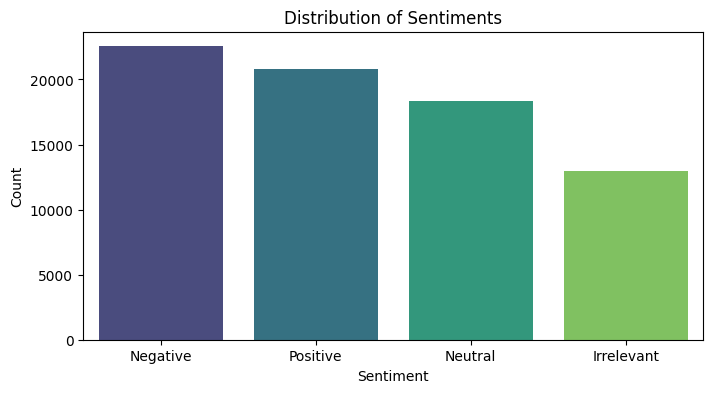

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count of each sentiment
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette="viridis")
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment_encoded'], test_size=0.2, random_state=42)

# Show the mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment Mapping:", label_mapping)


Sentiment Mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [22]:
# Drop rows where 'text' is NaN
df_cleaned = df.dropna(subset=['text'])

# Split data again after cleaning
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned['text'], df_cleaned['sentiment'], test_size=0.2, random_state=42
)

# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to top 5000 words
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF transformation complete!")



TF-IDF transformation complete!


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment_encoded'], test_size=0.2, random_state=42)

# Show the mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment Mapping:", label_mapping)


Sentiment Mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [25]:
# Drop rows where 'text' is NaN or empty string
df_cleaned = df.dropna(subset=['text'])
df_cleaned = df_cleaned[df_cleaned['text'] != '']  # Remove empty strings

# Split data again after cleaning
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned['text'], df_cleaned['sentiment_encoded'], test_size=0.2, random_state=42
)

# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)



LogisticRegression(max_iter=1000)

In [28]:
from sklearn.linear_model import LogisticRegression

# Initialize the model with max iterations
model = LogisticRegression(max_iter=1000)

# Train the model on TF-IDF transformed training data
model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)


In [29]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Detailed performance report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.53      0.60      2624
           1       0.73      0.79      0.76      4463
           2       0.69      0.64      0.66      3589
           3       0.68      0.75      0.71      4123

    accuracy                           0.70     14799
   macro avg       0.69      0.68      0.68     14799
weighted avg       0.70      0.70      0.69     14799



In [30]:
import joblib

# Save model and vectorizer
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [33]:
# Load the saved model and vectorizer
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Assuming df_cleaned and 'text' column are still available
vectorizer.fit(df_cleaned['text'])  # Fit the loaded vectorizer to the data


# Load the saved model and vectorizer
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Assuming df_cleaned and 'text' column are still available
vectorizer.fit(df_cleaned['text'])  # Fit the loaded vectorizer to the data


# Function to predict sentiment of a custom text
def predict_sentiment(text):
    pass

In [38]:
from sklearn.naive_bayes import MultinomialNB

# Train Naïve Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

# Predict & Evaluate
y_pred_nb = nb_clf.predict(X_test_tfidf)
print("Naïve Bayes Classifier:\n", classification_report(y_test, y_pred_nb))


Naïve Bayes Classifier:
               precision    recall  f1-score   support

           0       0.73      0.32      0.45      2624
           1       0.62      0.81      0.70      4463
           2       0.68      0.53      0.59      3589
           3       0.62      0.75      0.68      4123

    accuracy                           0.64     14799
   macro avg       0.66      0.60      0.61     14799
weighted avg       0.65      0.64      0.62     14799



In [41]:
import joblib

# Save the best model (e.g., Logistic Regression)
joblib.dump(model, "sentiment_model.pkl") # changed best_log_reg to model

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [42]:
import joblib

# Load the saved model and vectorizer
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_sentiment(text):
    text_tfidf = vectorizer.transform([text])  # Convert text to TF-IDF features
    prediction = model.predict(text_tfidf)[0]  # Predict sentiment
    sentiment_mapping = {0: "Irrelevant", 1: "Negative", 2: "Neutral", 3: "Positive"}
    return sentiment_mapping[prediction]

# Test the function
sample_text = "I love this product, it's amazing!"
print("Predicted Sentiment:", predict_sentiment(sample_text))


Predicted Sentiment: Negative


In [49]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
# Updated path to assume the CSV file is in the 'twitter_data' directory
# based on previous cells in the notebook
df = pd.read_csv("/content/twitter_data/twitter_training.csv")

# Ensure correct column names
df.columns = ["id", "entity", "sentiment", "text"]

# Map sentiments to numerical labels
sentiment_mapping = {"Irrelevant": 0, "Negative": 1, "Neutral": 2, "Positive": 3}
df["sentiment"] = df["sentiment"].map(sentiment_mapping)

# Handle missing values
df.dropna(inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["sentiment"], test_size=0.2, random_state=42)

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Evaluate model
y_pred = model.predict(X_test_tfidf)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Save model & vectorizer
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("✅ Model & Vectorizer saved successfully!")

Model Accuracy: 0.6968038380971687
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.53      0.60      2624
           1       0.73      0.79      0.76      4463
           2       0.69      0.64      0.66      3589
           3       0.68      0.75      0.71      4123

    accuracy                           0.70     14799
   macro avg       0.69      0.68      0.68     14799
weighted avg       0.70      0.70      0.69     14799

✅ Model & Vectorizer saved successfully!
